Importing libraries and Modells 

In [43]:
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Importera din befintliga preprocessing-modul
sys.path.append("..")
from backend.app.ml.preprocessing import prepare_data

Import CSV file and print the data

In [44]:
FILE_PATH = "../dataset/all_zones_complete_2025.csv"

# 1. Läs in och kör pipelinen (den skapar hour, month, day_of_week, is_weekend)
df_raw = pd.read_csv(FILE_PATH)
df = prepare_data(df_raw, include_lags=False)

# Verifiera att kalender-features finns
calendar_cols = ["hour", "day_of_week", "month", "is_weekend"]
print(f"Inläst data: {df.shape[0]} rader.")
print(f"Kalender-kolumner: {calendar_cols}")
display(df[["timestamp_local", "zone"] + calendar_cols].head(3))

Inläst data: 35040 rader.
Kalender-kolumner: ['hour', 'day_of_week', 'month', 'is_weekend']


,timestamp_local,zone,hour,day_of_week,month,is_weekend
0,2025-01-01 01:00:00+01:00,SE1,1,2,1,0
1,2025-01-01 02:00:00+01:00,SE1,2,2,1,0
2,2025-01-01 03:00:00+01:00,SE1,3,2,1,0


In [45]:
# Features för klustringen (spotpris + väderfaktorer)
FEATURES = ["spot_price_eur_mwh", "wind_speed_kmh", "temperature_c"]

# Rensa eventuella saknade värden
df_clean = df.dropna(subset=FEATURES).copy().reset_index(drop=True)

X = df_clean[FEATURES]



In [46]:
# Standardisera värdena
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Träningsdata klar: {X_scaled.shape[0]} rader fördelat på SE1–SE4.")

Träningsdata klar: 35040 rader fördelat på SE1–SE4.


In [47]:
# 1. Träna K-Means med exakt k=3 enligt kravspecen
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster_raw"] = kmeans.fit_predict(X_scaled)

# 2. Mappa klustren efter stigande snittpris så att Lågpris alltid blir billigast
price_order = (
    df_clean.groupby("cluster_raw")["spot_price_eur_mwh"].mean().sort_values().index
)

cluster_labels = {
    price_order[0]: "Lågpris",
    price_order[1]: "Medelpris",
    price_order[2]: "Högpris",
}

df_clean["price_cluster"] = df_clean["cluster_raw"].map(cluster_labels)
df_clean["cluster"] = df_clean["price_cluster"]

print("Klustring klar och mappad:")
display(
    df_clean.groupby("price_cluster")["spot_price_eur_mwh"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

Klustring klar och mappad:


,count,mean,min,max
price_cluster,,,,
Högpris,10926,65.64,-7.59,486.31
Lågpris,11553,17.21,-92.88,176.40
Medelpris,12561,24.81,-25.30,194.96


Träna modellen 

In [48]:
# 1. Träna K-Means med exakt k=3 enligt kravspecen
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster_raw"] = kmeans.fit_predict(X_scaled)

# 2. Mappa klustren efter stigande snittpris så att Lågpris alltid blir billigast
price_order = (
    df_clean.groupby("cluster_raw")["spot_price_eur_mwh"].mean().sort_values().index
)

cluster_labels = {
    price_order[0]: "Lågpris",
    price_order[1]: "Medelpris",
    price_order[2]: "Högpris",
}

df_clean["price_cluster"] = df_clean["cluster_raw"].map(cluster_labels)
df_clean["cluster"] = df_clean["price_cluster"]

print("Klustring klar och mappad:")
display(
    df_clean.groupby("price_cluster")["spot_price_eur_mwh"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

Klustring klar och mappad:


,count,mean,min,max
price_cluster,,,,
Högpris,10926,65.64,-7.59,486.31
Lågpris,11553,17.21,-92.88,176.40
Medelpris,12561,24.81,-25.30,194.96


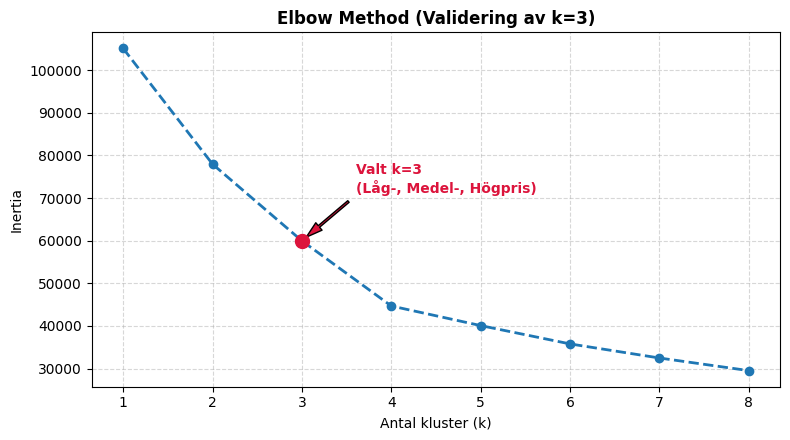

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Beräkna Inertia för k = 1 till 8
k_range = list(range(1, 9))
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plotta Elbow-kurvan
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, inertia, marker="o", linestyle="--", color="#1f77b4", linewidth=2)

# Markera k=3 enligt kravspecifikationen
k_spec = 3
spec_inertia = inertia[k_range.index(k_spec)]
plt.scatter([k_spec], [spec_inertia], color="crimson", s=100, zorder=5)

plt.annotate(
    f"Valt k={k_spec}\n(Låg-, Medel-, Högpris)",
    xy=(k_spec, spec_inertia),
    xytext=(k_spec + 0.6, spec_inertia + (max(inertia) - min(inertia)) * 0.15),
    arrowprops=dict(facecolor="crimson", shrink=0.08, width=1.5, headwidth=7),
    fontweight="bold",
    color="crimson",
)

plt.title("Elbow Method (Validering av k=3)", fontsize=12, fontweight="bold")
plt.xlabel("Antal kluster (k)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

--- Medelvärden per priskluster ---


,spot_price_eur_mwh,wind_speed_kmh,temperature_c
price_cluster,,,
Lågpris,17.21,21.05,6.85
Medelpris,24.81,10.05,14.17
Högpris,65.64,9.27,0.03



--- Svar på analyskravet (Typiska faktorer för Lågpris) ---
Spotpris:     17.21 EUR/MWh
Vindstyrka:   21.05 km/h
Temperatur:   6.85 °C


<Figure size 900x500 with 0 Axes>

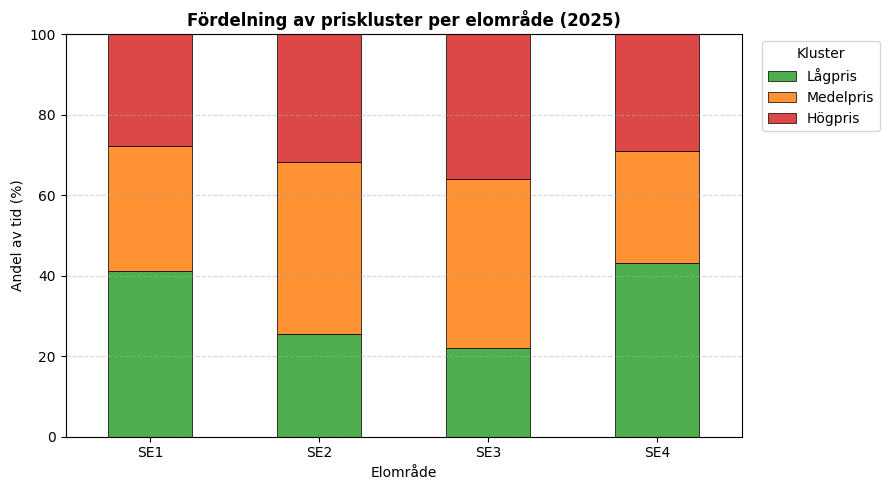

In [49]:
# 1. Sammanställ profil per kluster
cluster_summary = (
    df_clean.groupby("price_cluster")[FEATURES]
    .mean()
    .loc[["Lågpris", "Medelpris", "Högpris"]]
    .round(2)
)

print("--- Medelvärden per priskluster ---")
display(cluster_summary)

low = cluster_summary.loc["Lågpris"]
print("\n--- Svar på analyskravet (Typiska faktorer för Lågpris) ---")
print(f"Spotpris:     {low['spot_price_eur_mwh']} EUR/MWh")
print(f"Vindstyrka:   {low['wind_speed_kmh']} km/h")
print(f"Temperatur:   {low['temperature_c']} °C")

# 2. Stapeldiagram över zonernas fördelning
zone_dist = (
    pd.crosstab(df_clean["zone"], df_clean["price_cluster"], normalize="index")[
        ["Lågpris", "Medelpris", "Högpris"]
    ]
    * 100
)

plt.figure(figsize=(9, 5))
ax = zone_dist.plot(
    kind="bar",
    stacked=True,
    color=["#2ca02c", "#ff7f0e", "#d62728"],
    figsize=(9, 5),
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)
plt.title("Fördelning av priskluster per elområde (2025)", fontweight="bold")
plt.xlabel("Elområde")
plt.ylabel("Andel av tid (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Kluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

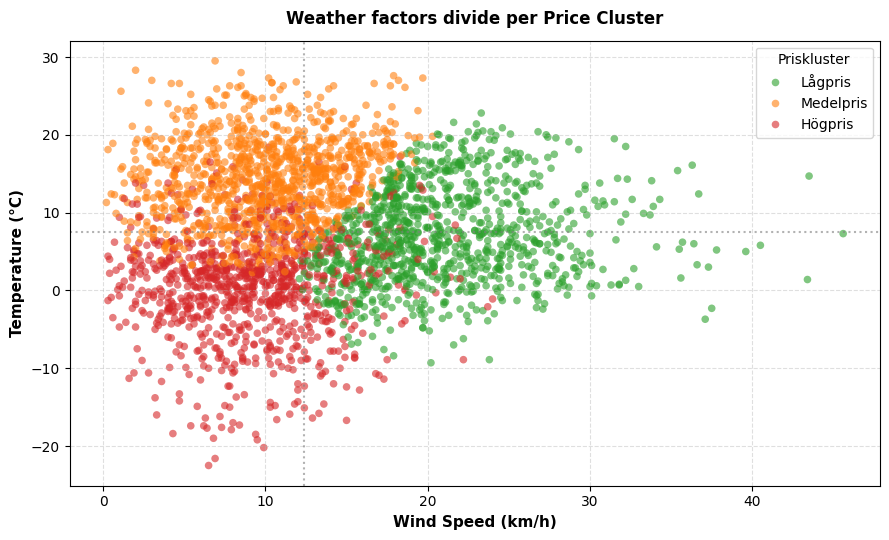

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Skapa ett representativt urval för att undvika överlappande punkter (~35 000 rader)
sample_df = df_clean.sample(n=min(3000, len(df_clean)), random_state=42)

palette = {
    "Lågpris": "#2ca02c",  # Grön
    "Medelpris": "#ff7f0e",  # Orange
    "Högpris": "#d62728",  # Röd
}

plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=sample_df,
    x="wind_speed_kmh",
    y="temperature_c",
    hue="price_cluster",
    hue_order=["Lågpris", "Medelpris", "Högpris"],
    palette=palette,
    alpha=0.6,
    edgecolor="none",
    s=30,
)

plt.title(
    "Weather factors divide per Price Cluster",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Wind Speed (km/h)", fontsize=11, fontweight="bold")
plt.ylabel("Temperature (°C)", fontsize=11, fontweight="bold")
plt.axvline(
    x=sample_df["wind_speed_kmh"].median(), color="gray", linestyle=":", alpha=0.6
)
plt.axhline(
    y=sample_df["temperature_c"].median(), color="gray", linestyle=":", alpha=0.6
)

plt.legend(title="Priskluster", frameon=True, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()